# Домашнее задание №5
## Звёзды | Солнечные пятна | Баскетболисты NBA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.grid'] = True

---
# 1. Звёзды

In [2]:
stars = pd.read_csv('stars.csv')
stars.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star color,Star type,Spectral Class
0,9787,6264.840272,38.115,3.37,White,3,G
1,23033,1204.275297,0.013,19.10,blue-white,2,G
2,25846,130.777071,0.011,-9.31,White,3,G
3,9184,0.083454,1.578,3.68,White-Yellow,2,M
4,25298,679686.835011,6.318,15.80,Red,5,A


In [3]:
stars.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star color              240 non-null    str    
 5   Star type               240 non-null    int64  
 6   Spectral Class          240 non-null    str    
dtypes: float64(3), int64(2), str(2)
memory usage: 13.3 KB


### 1.1 Нормализация столбца `Star color`

In [4]:
def normalize_color(c):
    c = str(c).strip().lower()
    c = c.replace('-', ' ').replace('_', ' ')
    return ' '.join(w.capitalize() for w in c.split())

stars['Star color'] = stars['Star color'].apply(normalize_color)
print(stars['Star color'].value_counts())

Star color
Red             52
Blue White      43
Orange Red      34
Blue            29
Yellow White    28
Orange          16
White           14
White Yellow    10
Brown           10
Yellow           4
Name: count, dtype: int64


### 1.2 Добавление строкового столбца типа звезды

In [5]:
type_map = {
    0: 'Red Dwarf',
    1: 'Brown Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Super Giants',
    5: 'Hyper Giants'
}
stars['Star type name'] = stars['Star type'].map(type_map)
stars[['Star type', 'Star type name']].value_counts().sort_index()

Star type  Star type name
0          Red Dwarf         44
1          Brown Dwarf       32
2          White Dwarf       34
3          Main Sequence     37
4          Super Giants      46
5          Hyper Giants      47
Name: count, dtype: int64

### 1.3 Добавление числового столбца спектрального класса

In [6]:
spectral_map = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
stars['Spectral Class num'] = stars['Spectral Class'].map(spectral_map)
stars[['Spectral Class', 'Spectral Class num']].drop_duplicates().sort_values('Spectral Class num')

,Spectral Class,Spectral Class num
5,O,0
10,B,1
4,A,2
16,F,3
0,G,4
7,K,5
3,M,6


### 1.4 Количество звёзд по цвету, типу и спектральному классу

In [7]:
print("По цвету:")
print(stars['Star color'].value_counts(), '\n')
print("По типу:")
print(stars['Star type name'].value_counts(), '\n')
print("По спектральному классу:")
print(stars['Spectral Class'].value_counts().sort_index())

По цвету:
Star color
Red             52
Blue White      43
Orange Red      34
Blue            29
Yellow White    28
Orange          16
White           14
White Yellow    10
Brown           10
Yellow           4
Name: count, dtype: int64 

По типу:
Star type name
Hyper Giants     47
Super Giants     46
Red Dwarf        44
Main Sequence    37
White Dwarf      34
Brown Dwarf      32
Name: count, dtype: int64 

По спектральному классу:
Spectral Class
A    32
B    29
F    31
G    43
K    35
M    38
O    32
Name: count, dtype: int64


### 1.5 Статистики абсолютной звёздной величины по типу

                 Min  Mean    Max
Star type name                   
Brown Dwarf    -9.54  5.62  19.56
Hyper Giants   -7.96  4.74  19.53
Main Sequence  -9.99  5.96  18.50
Red Dwarf      -8.46  4.58  19.07
Super Giants   -9.63  4.22  19.90
White Dwarf    -9.23  4.40  19.66


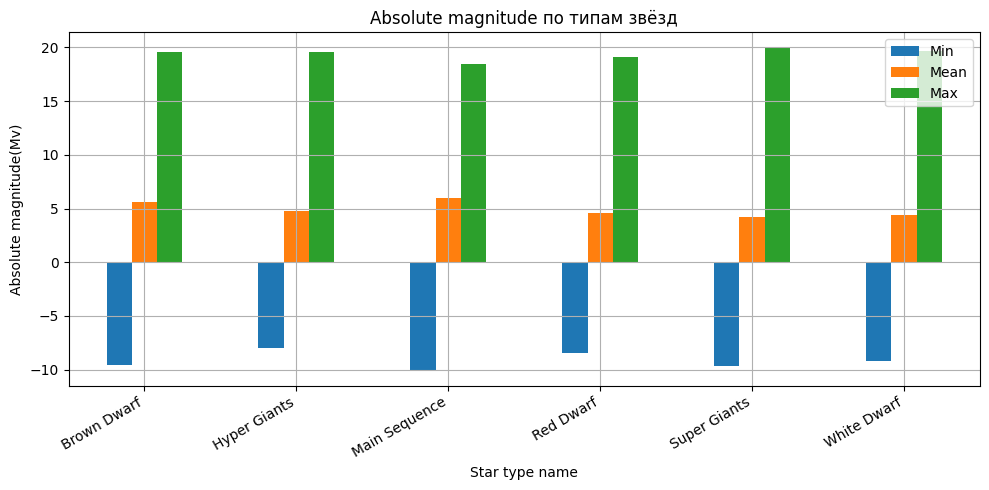

In [8]:
stats_type = stars.groupby('Star type name')['Absolute magnitude(Mv)'].agg(['min','mean','max'])
stats_type.columns = ['Min', 'Mean', 'Max']
print(stats_type.round(2))
stats_type.plot(kind='bar', title='Absolute magnitude по типам звёзд')
plt.ylabel('Absolute magnitude(Mv)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 1.6 Статистики температуры по спектральному классу

                 Min     Mean    Max
Spectral Class                      
A               1052  20054.0  43684
B               1294  15003.0  39978
F                913  16899.0  43673
G                869  18827.0  49853
K                868  16711.0  45600
M                957  17106.0  35620
O               1164  13418.0  34082


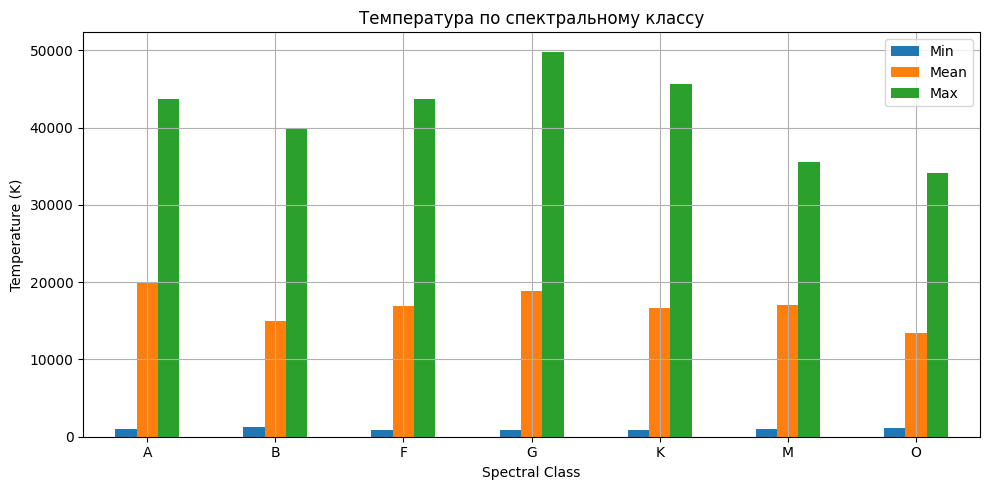

In [9]:
stats_class = stars.groupby('Spectral Class')['Temperature (K)'].agg(['min','mean','max'])
stats_class.columns = ['Min', 'Mean', 'Max']
print(stats_class.round(0))
stats_class.plot(kind='bar', title='Температура по спектральному классу')
plt.ylabel('Temperature (K)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.7 Попарные корреляции числовых столбцов

                        Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
Temperature (K)                   1.000             0.043         0.022   
Luminosity(L/Lo)                  0.043             1.000         0.043   
Radius(R/Ro)                      0.022             0.043         1.000   
Absolute magnitude(Mv)           -0.025             0.045        -0.007   
Star type                         0.705             0.080         0.061   
Spectral Class num                0.069            -0.033        -0.036   

                        Absolute magnitude(Mv)  Star type  Spectral Class num  
Temperature (K)                         -0.025      0.705               0.069  
Luminosity(L/Lo)                         0.045      0.080              -0.033  
Radius(R/Ro)                            -0.007      0.061              -0.036  
Absolute magnitude(Mv)                   1.000     -0.010              -0.036  
Star type                               -0.010      1.000               0.

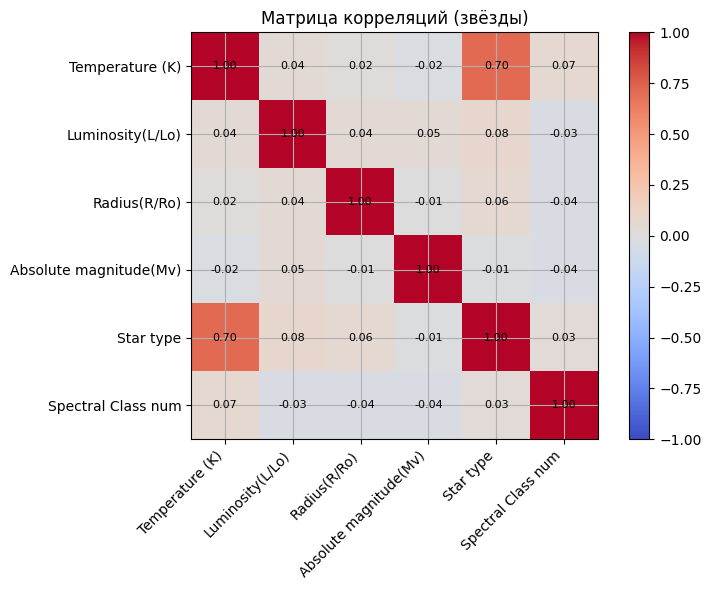

In [10]:
num_cols = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
            'Absolute magnitude(Mv)', 'Star type', 'Spectral Class num']
corr = stars[num_cols].corr()
print(corr.round(3))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Матрица корреляций (звёзды)')
plt.tight_layout()
plt.show()

---
# 2. Солнечные пятна

In [11]:
sunspot = pd.read_csv('sunspot.csv')
sunspot.head()

,year,month,day,Number of spots,Standard Deviation,Observations
0,1818,1,1,48.6,7.8,6
1,1818,1,2,49.8,8.6,5
2,1818,1,3,52.2,4.6,2
3,1818,1,4,51.1,9.7,3
4,1818,1,5,35.8,5.6,9


### 2.1 Создание столбца с полной датой

In [12]:
sunspot['date'] = pd.to_datetime(sunspot[['year','month','day']])
sunspot = sunspot.drop(columns=['year','month','day'])
sunspot.head()

,Number of spots,Standard Deviation,Observations,date
0,48.6,7.8,6,1818-01-01
1,49.8,8.6,5,1818-01-02
2,52.2,4.6,2,1818-01-03
3,51.1,9.7,3,1818-01-04
4,35.8,5.6,9,1818-01-05


### 2.2 Замена `-1` на `np.nan`

In [13]:
sunspot.replace(-1, np.nan, inplace=True)
print(f"Пропуски: {sunspot.isna().sum().to_dict()}")
sunspot.head()

Пропуски: {'Number of spots': 3662, 'Standard Deviation': 3662, 'Observations': 0, 'date': 0}


,Number of spots,Standard Deviation,Observations,date
0,48.6,7.8,6,1818-01-01
1,49.8,8.6,5,1818-01-02
2,52.2,4.6,2,1818-01-03
3,51.1,9.7,3,1818-01-04
4,35.8,5.6,9,1818-01-05


### 2.3 Годовая статистика: дни с данными и сумма пятен

In [14]:
annual = sunspot.groupby(sunspot['date'].dt.year).agg(
    days_with_data=('Number of spots', 'count'),
    total_spots=('Number of spots', 'sum')
).rename_axis('year')
annual.head(10)

,days_with_data,total_spots
year,,
1818,348,15310.7
1819,354,21018.3
1820,352,25600.5
1821,344,27286.6
1822,342,26959.9
1823,345,24974.5
1824,348,20654.0
1825,336,14315.1
1826,350,8075.7


### 2.4 Графики годовой статистики

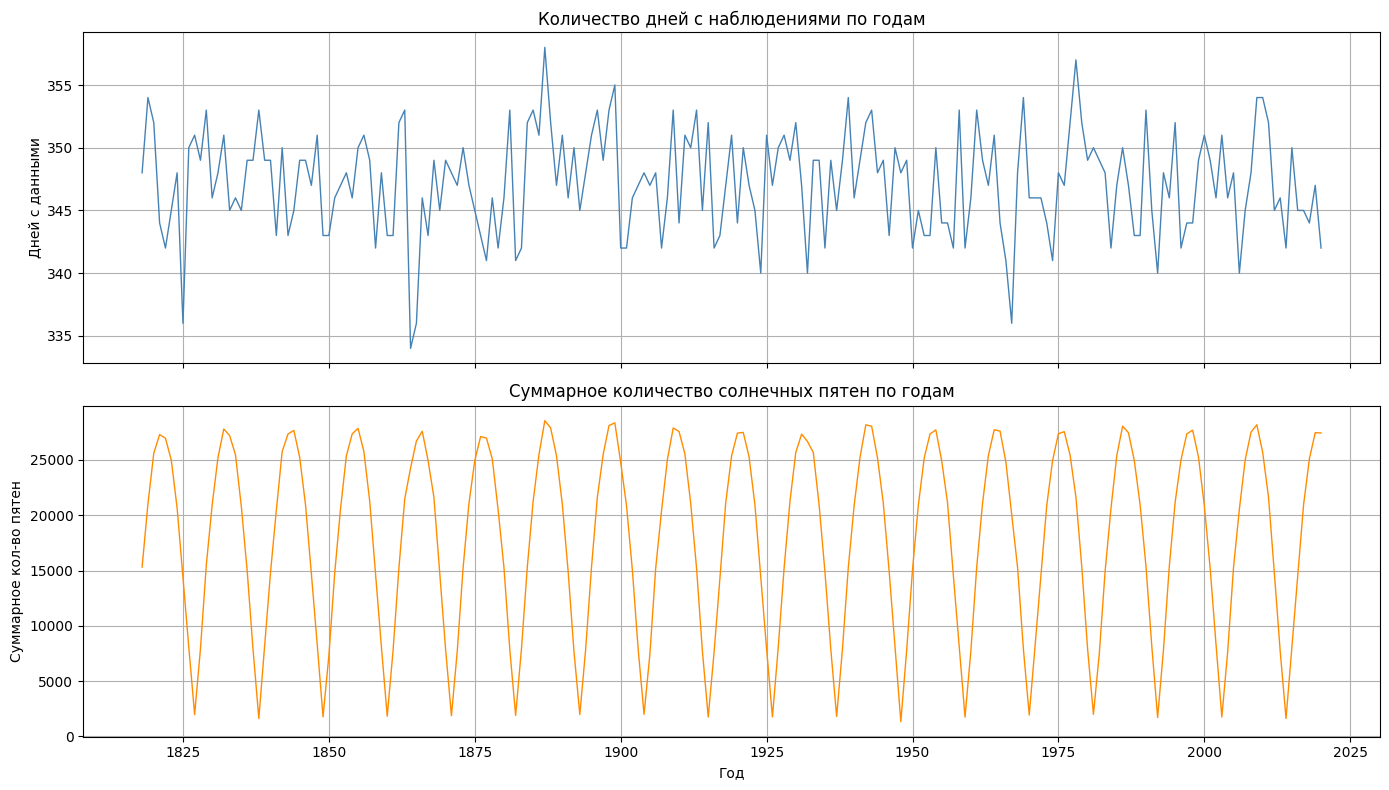

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(annual.index, annual['days_with_data'], color='steelblue', lw=1)
axes[0].set_ylabel('Дней с данными')
axes[0].set_title('Количество дней с наблюдениями по годам')

axes[1].plot(annual.index, annual['total_spots'], color='darkorange', lw=1)
axes[1].set_ylabel('Суммарное кол-во пятен')
axes[1].set_title('Суммарное количество солнечных пятен по годам')
axes[1].set_xlabel('Год')

plt.tight_layout()
plt.show()

### 2.5 Среднее количество пятен по месяцам (данные с 2000 года)

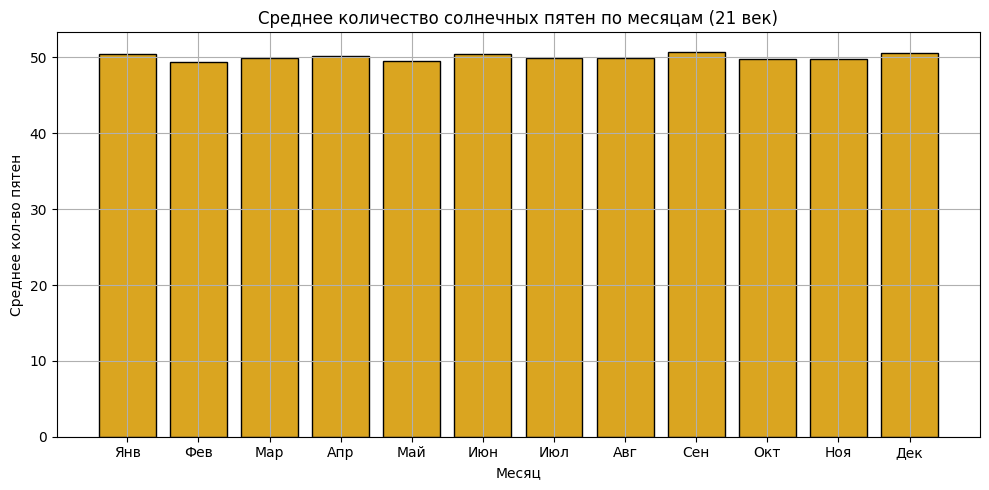

In [16]:
s21 = sunspot[sunspot['date'].dt.year >= 2000].copy()
monthly_avg = s21.groupby(s21['date'].dt.month)['Number of spots'].mean()

month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), monthly_avg.values, color='goldenrod', edgecolor='black')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Месяц')
ax.set_ylabel('Среднее кол-во пятен')
ax.set_title('Среднее количество солнечных пятен по месяцам (21 век)')
plt.tight_layout()
plt.show()

---
# 3. Баскетболисты NBA

In [17]:
nba = pd.read_csv('NBA.csv')
nba.head()

,Player Full Name,Birth Date,Year Start,Year End,Position,Height,Wingspan,Weight
0,Scottie James,1925-06-13,1950,1960,F,191.2,195.7,239.6
1,James Jones,1982-10-27,2003,2017,G,197.8,201.1,190.8
2,Tim Wade,1980-08-01,2001,2017,G,196.1,201.6,198.9
3,Dwyane Durant,1983-08-14,2006,2017,F,196.5,198.3,223.9
4,Dirk James,1952-05-09,1971,1981,F,215.4,218.8,210.9


In [18]:
nba.info()

<class 'pandas.DataFrame'>
RangeIndex: 4550 entries, 0 to 4549
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Player Full Name  4550 non-null   str    
 1   Birth Date        4550 non-null   str    
 2   Year Start        4550 non-null   int64  
 3   Year End          4550 non-null   int64  
 4   Position          4550 non-null   str    
 5   Height            4550 non-null   float64
 6   Wingspan          4550 non-null   float64
 7   Weight            4550 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 284.5 KB


### 3.1 Перевод веса из фунтов в килограммы

In [19]:
nba['Weight_kg'] = nba['Weight'] * 0.45359237
nba['Weight_kg'] = nba['Weight_kg'].round(2)
nba[['Player Full Name','Weight','Weight_kg']].head()

,Player Full Name,Weight,Weight_kg
0,Scottie James,239.6,108.68
1,James Jones,190.8,86.55
2,Tim Wade,198.9,90.22
3,Dwyane Durant,223.9,101.56
4,Dirk James,210.9,95.66


### 3.2 Самый высокий и самый низкий игрок

In [20]:
tallest = nba.loc[nba['Height'].idxmax()]
shortest = nba.loc[nba['Height'].idxmin()]
print(f"Самый высокий: {tallest['Player Full Name']} — {tallest['Height']} см")
print(f"Самый низкий:  {shortest['Player Full Name']} — {shortest['Height']} см")

Самый высокий: Michael Jackson — 230.1 см
Самый низкий:  Dirk Bryant — 168.8 см


### 3.3 Самый лёгкий и самый тяжёлый игрок

In [21]:
heaviest = nba.loc[nba['Weight_kg'].idxmax()]
lightest  = nba.loc[nba['Weight_kg'].idxmin()]
print(f"Самый тяжёлый: {heaviest['Player Full Name']} — {heaviest['Weight_kg']:.1f} кг")
print(f"Самый лёгкий:  {lightest['Player Full Name']}  — {lightest['Weight_kg']:.1f} кг")

Самый тяжёлый: Tracy Barkley — 149.1 кг
Самый лёгкий:  Allen Wilson  — 61.0 кг


### 3.4 Самый маленький и самый большой размах рук

In [22]:
max_wing = nba.loc[nba['Wingspan'].idxmax()]
min_wing  = nba.loc[nba['Wingspan'].idxmin()]
print(f"Макс. размах: {max_wing['Player Full Name']} — {max_wing['Wingspan']} см")
print(f"Мин. размах:  {min_wing['Player Full Name']} — {min_wing['Wingspan']} см")

Макс. размах: Michael Jackson — 239.5 см
Мин. размах:  Shaquille Jackson — 172.1 см


### 3.5 Корреляции: рост, вес, размах рук; диаграмма рассеяния

Корреляции:
           Height  Weight_kg  Wingspan
Height      1.000      0.529     0.961
Weight_kg   0.529      1.000     0.509
Wingspan    0.961      0.509     1.000


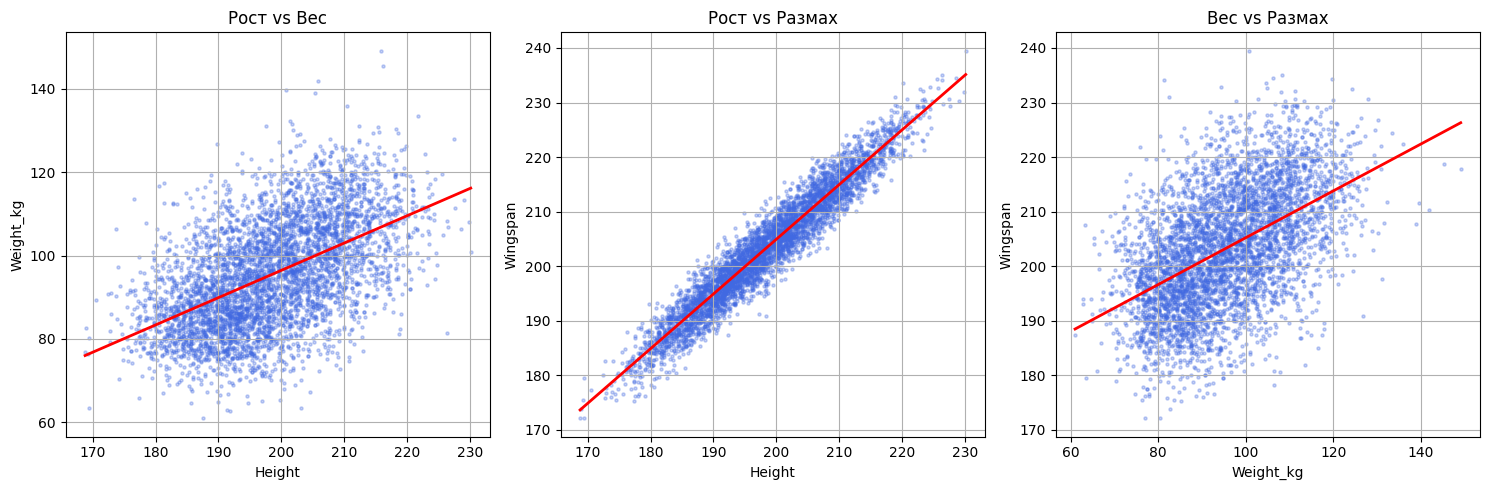

In [23]:
phys = nba[['Height', 'Weight_kg', 'Wingspan']].dropna()
print("Корреляции:")
print(phys.corr().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [('Height','Weight_kg','Рост vs Вес'),
         ('Height','Wingspan','Рост vs Размах'),
         ('Weight_kg','Wingspan','Вес vs Размах')]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(phys[x], phys[y], alpha=0.3, s=5, color='royalblue')
    # Linear regression
    m, b = np.polyfit(phys[x], phys[y], 1)
    xs = np.linspace(phys[x].min(), phys[x].max(), 100)
    ax.plot(xs, m*xs + b, color='red', lw=2)
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title(title)
plt.tight_layout()
plt.show()

### 3.6 Столбец с продолжительностью карьеры

In [24]:
nba['Career Length'] = nba['Year End'] - nba['Year Start']
nba[['Player Full Name','Year Start','Year End','Career Length']].head()

,Player Full Name,Year Start,Year End,Career Length
0,Scottie James,1950,1960,10
1,James Jones,2003,2017,14
2,Tim Wade,2001,2017,16
3,Dwyane Durant,2006,2017,11
4,Dirk James,1971,1981,10


### 3.7 Индекс массы тела (ИМТ)

In [25]:
nba['BMI'] = nba['Weight_kg'] / (nba['Height'] / 100) ** 2
nba['BMI'] = nba['BMI'].round(2)
nba[['Player Full Name','Height','Weight_kg','BMI']].head()

,Player Full Name,Height,Weight_kg,BMI
0,Scottie James,191.2,108.68,29.73
1,James Jones,197.8,86.55,22.12
2,Tim Wade,196.1,90.22,23.46
3,Dwyane Durant,196.5,101.56,26.30
4,Dirk James,215.4,95.66,20.62


### 3.8 Зависимость показателей от позиции

          Career Length  Height  Weight_kg  Wingspan
Position                                            
C                  9.38  209.58     110.90    214.60
F                  9.45  199.87      97.77    204.75
F-C                9.53  209.48     109.37    214.24
G                  9.37  189.85      83.84    194.74
G-F                9.35  200.46      97.66    205.53


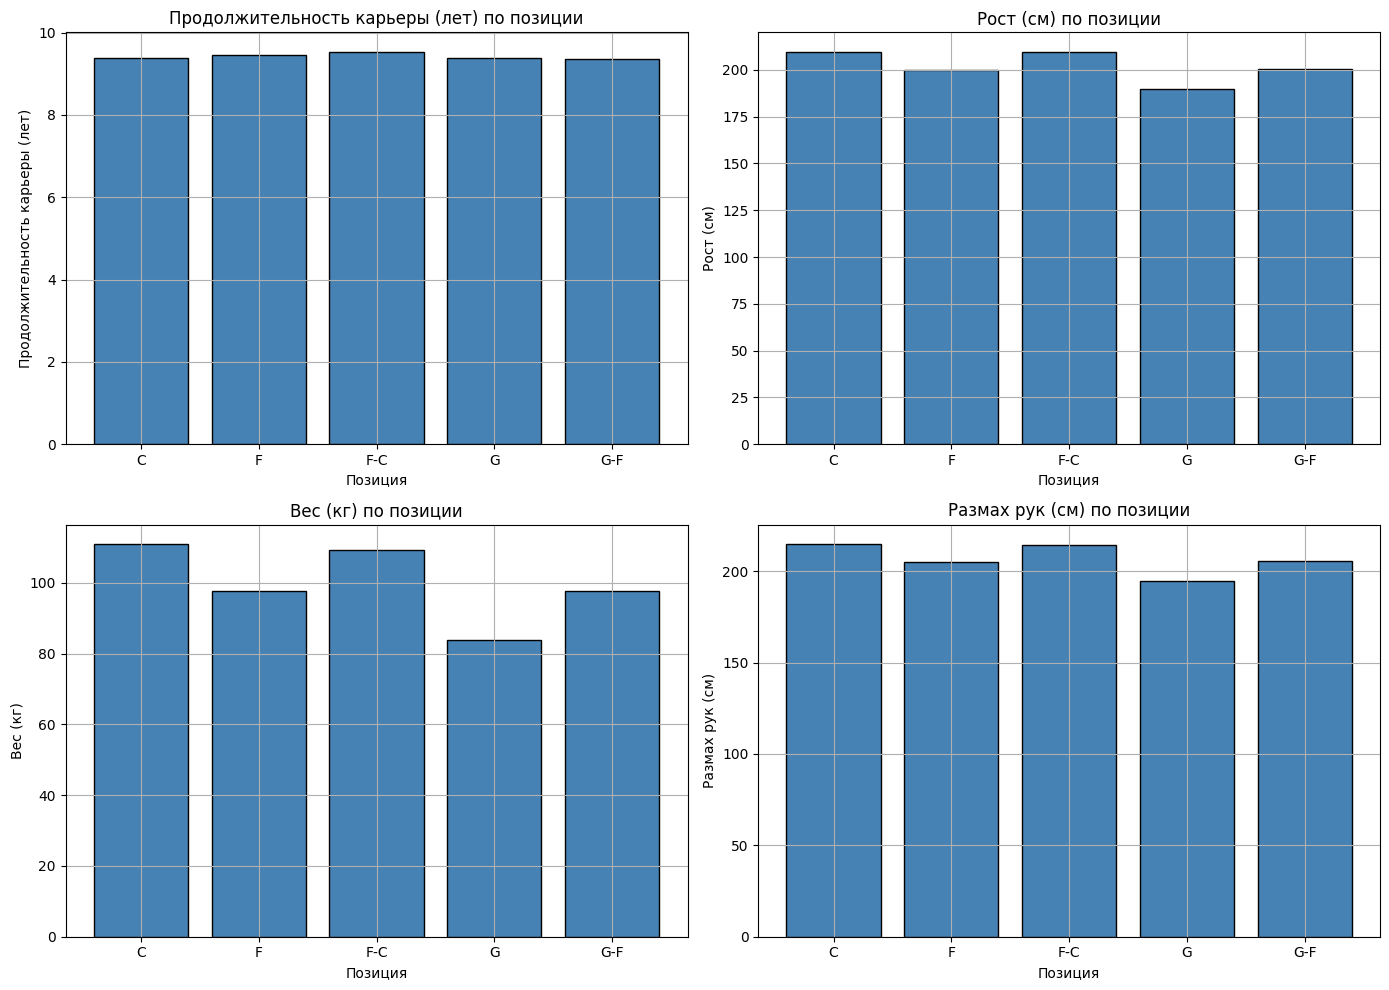

In [26]:
pos_stats = nba.groupby('Position')[['Career Length','Height','Weight_kg','Wingspan']].mean()
print(pos_stats.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [('Career Length','Продолжительность карьеры (лет)'),
           ('Height','Рост (см)'),
           ('Weight_kg','Вес (кг)'),
           ('Wingspan','Размах рук (см)')]
for ax, (col, label) in zip(axes.flat, metrics):
    ax.bar(pos_stats.index, pos_stats[col], color='steelblue', edgecolor='black')
    ax.set_xlabel('Позиция'); ax.set_ylabel(label); ax.set_title(label + ' по позиции')
plt.tight_layout()
plt.show()

### 3.9 Изменение показателей с течением времени

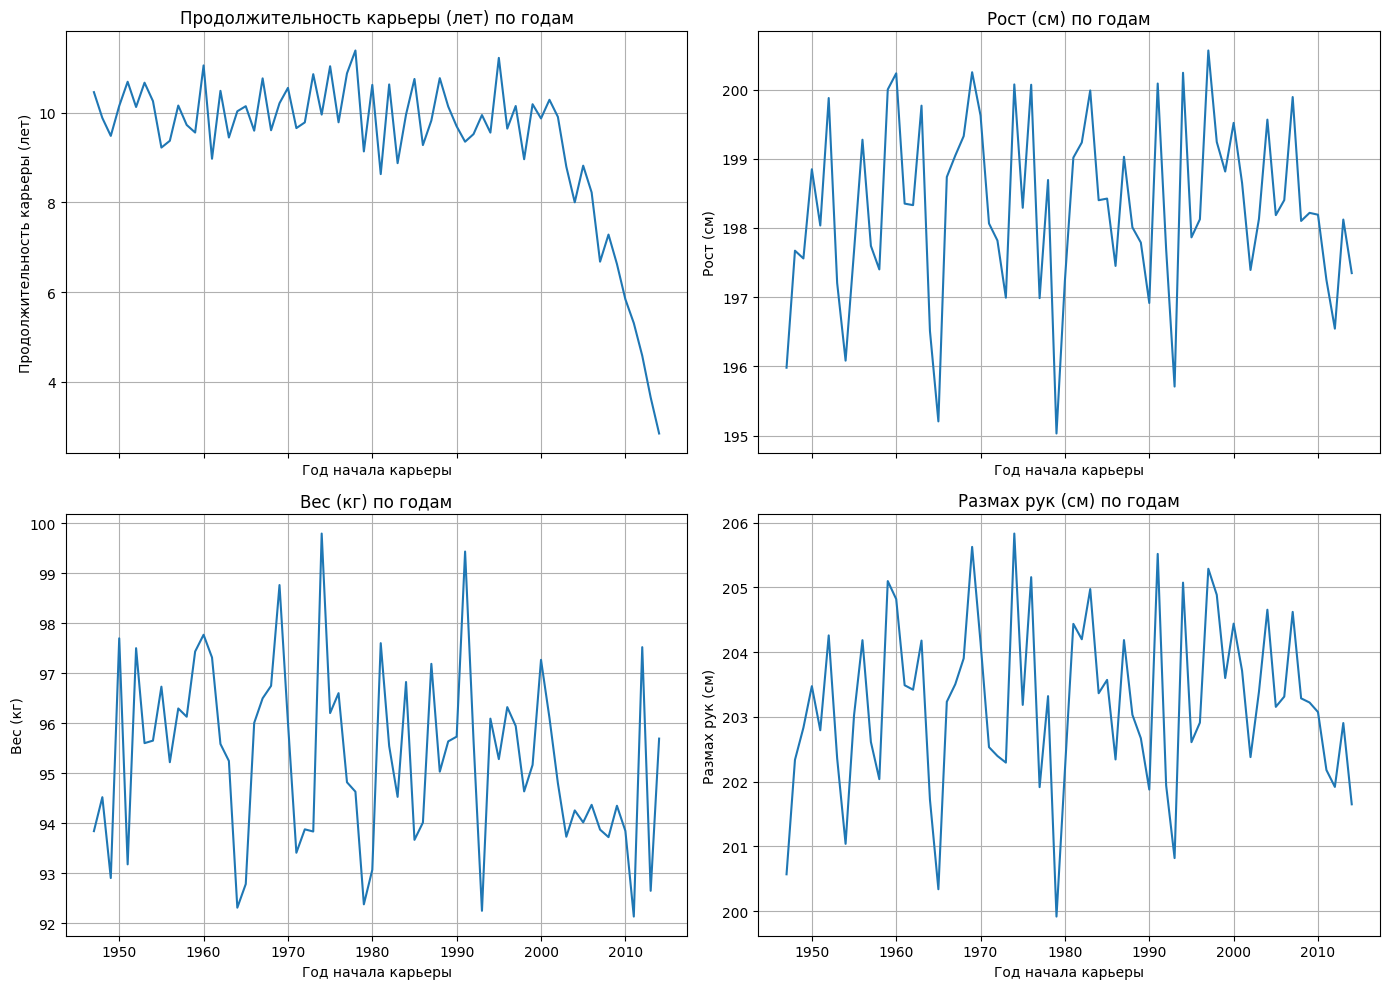

In [27]:
time_stats = nba.groupby('Year Start')[['Career Length','Height','Weight_kg','Wingspan']].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
metrics = [('Career Length','Продолжительность карьеры (лет)'),
           ('Height','Рост (см)'),
           ('Weight_kg','Вес (кг)'),
           ('Wingspan','Размах рук (см)')]
for ax, (col, label) in zip(axes.flat, metrics):
    ax.plot(time_stats.index, time_stats[col], lw=1.5)
    ax.set_xlabel('Год начала карьеры'); ax.set_ylabel(label); ax.set_title(label + ' по годам')
plt.tight_layout()
plt.show()